[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giulia-open-lab/sionna-rt-course/blob/main/notebooks/01_instructor_demo.ipynb)

# Ray tracing for radio propagation with Sionna RT

**Lecture demo** for the MSc course *Radio Propagation*.

This notebook is run live in class. It explains what a ray tracer for radio propagation is, what
Sionna RT does, and pairs every demonstration with code, figures and a physical interpretation.
The 2-hour lab (`02_lab_student.ipynb`) builds on it.

Written and tested with `sionna-rt` 2.2.0 and Python 3.13, on a GPU (CUDA) and on a CPU (LLVM).

## Learning objectives

After this lecture you can:

1. Explain when deterministic ray tracing is preferable to empirical models (Okumura-Hata,
   COST-231) and to stochastic models (3GPP TR 38.901), and when it is not.
2. Describe the physics a ray tracer applies (geometrical optics with Fresnel coefficients, the
   uniform theory of diffraction, diffuse scattering) and how rays are found (image method,
   shooting and bouncing rays).
3. Set up a Sionna RT scene: load and render it, inspect and change ITU-R P.2040 materials,
   configure antennas, polarization and frequency, place transmitters and receivers.
4. Compute propagation paths and interpret them (interaction types, delays, path gains).
5. Validate a ray tracer against the Friis formula and the two-ray model.
6. Go from paths to the channel: impulse response, power delay profile, RMS delay spread,
   frequency response and coherence bandwidth, in LoS and NLoS.
7. Compute and interpret radio maps, and explain the effect of the number of interactions,
   diffraction and diffuse scattering.
8. Discuss frequency dependence, modelling limitations and good practice.

## Prerequisites

- **Propagation:** Friis equation; dB and dBm; reflection of plane waves and Fresnel coefficients
  (TE/TM, Brewster angle); complex permittivity; two-ray model and breakpoint distance;
  knife-edge and UTD diffraction; multipath, power delay profile, delay spread, coherence
  bandwidth; path-loss exponent; Doppler shift.
- **Python:** functions, NumPy arrays, basic matplotlib, running Jupyter cells.
- No prior knowledge of Sionna.

## Conventions

- **Path gain** $G=\lvert a\rvert^2$ (linear, $\le 1$) and $G_\mathrm{dB}=10\log_{10}G\le 0$:
  this is Sionna's convention and we use it throughout. **Path loss** $\mathrm{PL}=-G_\mathrm{dB}$
  appears only when we compare with 3GPP formulas.
- Received power: $P_\mathrm{rx}\,[\mathrm{dBm}]=P_\mathrm{tx}\,[\mathrm{dBm}]+G_\mathrm{dB}$; the
  antenna gains are included in $G$ (0 dBi for isotropic antennas).
- SI units in the code (m, Hz, s, rad); GHz, ns and degrees in text and plots.
- Carrier frequency 3.5 GHz (5G NR band n78) unless stated otherwise.

## Plan (about 60 min)

| § | Topic | min |
|---|---|---|
| 1 | Why ray tracing | 6 |
| 2 | What Sionna is | 3 |
| 3 | Setup: GPU and CPU variants | 2 |
| 4 | The scene and its radio materials | 5 |
| 5 | Radio devices: antennas, polarization, frequency | 4 |
| 6 | First paths with `PathSolver` | 6 |
| 7 | Physical validation: Friis and the two-ray model | 9 |
| 8 | From paths to the channel | 8 |
| 9 | Radio maps | 7 |
| 10 | Parametric study: frequency and materials | 4 |
| 11 | Mobility and Doppler (optional) | 2 |
| 12 | Limitations and good practice | 3 |
| 13 | Summary and references | 1 |

## 1. Why ray tracing?

There are three families of propagation models:

| | Empirical | Stochastic, geometry-based | Deterministic (ray tracing) |
|---|---|---|---|
| Examples | Okumura-Hata, COST-231 Hata | 3GPP TR 38.901 (UMi, UMa, InH, ...) | Sionna RT, commercial ray tracers |
| Built from | Curve fits to measurements | Statistics of measured channels: path loss, delay and angle spreads, K-factor, ... | High-frequency approximation of Maxwell's equations applied to a 3D model of the site |
| Output | Median path loss vs distance | Random channels with realistic statistics | The channel at a given position in a given place |
| Validity | Okumura-Hata: 150-1500 MHz, 1-20 km, base station 30-200 m high; COST-231 Hata extends it to 1.5-2 GHz | 0.5-100 GHz, standard scenarios | Objects much larger than the wavelength, known geometry and materials |
| Cost | Negligible | Low | High (GPUs help) |
| Site-specific | No | No | **Yes** |

**When ray tracing is worth it.** When the geometry decides the result: small cells and
millimetre-wave planning (LoS or not changes everything), beam management, localization and
sensing, digital twins of a site, data sets for machine learning. **When it is not.** When you
need statistics over many environments (use 3GPP models), when the 3D model or the material data
are poor, for a quick link budget, or when the propagation is dominated by effects the ray tracer
does not model (vegetation, rain, atmospheric gases).

**The physics.** *Geometrical optics* (GO): at high frequency, energy travels along rays. A ray
spreads as $1/r$ and, at each interaction, its field is multiplied by a coefficient (for example
the Fresnel reflection coefficient). GO alone predicts no field at all in shadow regions. The
*uniform theory of diffraction* (UTD) adds rays diffracted by edges (Keller's cone) and keeps the
total field continuous across shadow boundaries.

**Finding the rays.**
- *Image method:* mirror the source in every reflecting surface, then the images in other surfaces,
  and so on. It gives exact specular paths, but the number of candidates grows as $N^k$ for $N$
  surfaces and $k$ reflections.
- *Shooting and bouncing rays* (SBR): launch many rays in all directions and follow them. It scales
  well, but it is a Monte Carlo method: with too few rays a path can be missed.
- **Sionna RT** combines both: SBR finds candidate sequences of interactions, the image method
  computes the exact specular paths for these candidates, and hashing removes duplicates. Radio
  maps use SBR only.

**What Sionna RT 2.2 models:** line of sight, specular reflection, transmission (refraction)
through objects modelled as thin slabs (the rays are not deflected), diffuse scattering (when a
material has a scattering coefficient larger than 0), first-order diffraction on wedges and edges
(UTD, one diffraction per path), antenna patterns and polarization, Doppler shifts from moving
objects. **What it does not model:** more than one diffraction per path, diffraction by interior
wedges, vegetation, rain and gaseous absorption. The path coefficients are computed at the
carrier frequency and assumed constant over the bandwidth.

> **Instructor notes**
> - **Emphasise:** ray tracing is site-specific and only as good as its geometry and materials; it complements 3GPP models, it does not replace them.
> - **Ask the class:** you must plan a 28 GHz small cell on one specific street corner. Which model family do you use, and why?
>   *Expected answer:* ray tracing: at 28 GHz LoS or NLoS decides everything and it depends on this corner; a 3GPP model only gives statistics over many corners, and Okumura-Hata is far outside its frequency range.
> - **Time:** about 6 min.

## 2. What Sionna is

[Sionna](https://nvlabs.github.io/sionna/) is an open-source (Apache-2.0) library by NVIDIA with
three parts:

- **Sionna PHY:** link-level simulation (channel coding, modulation, MIMO, OFDM, channel models
  including 3GPP), based on PyTorch since version 2.0.
- **Sionna SYS:** system-level simulation (scheduling, power control, link abstraction), also
  based on PyTorch.
- **Sionna RT:** the ray tracer we use today. It is built on
  [Mitsuba 3](https://www.mitsuba-renderer.org/), a research renderer that stores the scene and
  intersects rays with triangles (it also renders the images of the scene you will see), and on
  [Dr.Jit](https://drjit.readthedocs.io/), a just-in-time compiler that turns the Python code into
  GPU (CUDA) or CPU (LLVM) kernels. Sionna RT does not depend on TensorFlow or PyTorch; results
  can be exported to NumPy, PyTorch, JAX or TensorFlow (`out_type=...`).

**Differentiability.** Dr.Jit can compute the gradient of any output (a path gain, a radio map)
with respect to scene parameters such as material properties, positions, orientations or antenna
patterns. This is used, for example, to calibrate material parameters against measurements or to
optimise the position of a transmitter. We will not use gradients today.

> **Instructor notes**
> - **Emphasise:** the same Python code runs on a GPU or on a CPU (Mitsuba 'variants'); the first call of a function is slower because Dr.Jit compiles it.
> - **Ask the class:** why could gradients with respect to material parameters be useful to a propagation engineer?
>   *Expected answer:* to calibrate the permittivity and conductivity of the materials so that the ray tracer matches measured path gains (gradient descent on the error).
> - **Time:** about 3 min.

## 3. Setup: GPU and CPU variants

Run the next cell first. On Google Colab it installs `sionna-rt` and restarts the runtime, as the
official Sionna tutorials do: when the runtime has restarted, run the cell again.

Sionna RT runs on a Mitsuba **variant**, selected automatically when `sionna.rt` is imported:
`cuda_ad_mono_polarized` on an NVIDIA GPU, otherwise `llvm_ad_mono_polarized` on the CPU (this
needs the LLVM library). `ad` means automatic differentiation, `mono` a single wavelength,
`polarized` that every ray carries its polarization state, so that TE and TM reflection
coefficients and antenna polarization are applied correctly.

In [1]:
# Setup: install Sionna RT if it is missing (Colab), select the Mitsuba variant, print versions
import importlib.util
import os
import sys

SIONNA_RT_VERSION = "2.2.0"   # version this notebook was written and tested with
FORCE_CPU = False             # True: use the CPU (LLVM) variant even if a GPU is available

if importlib.util.find_spec("sionna") is None:
    if "google.colab" in sys.modules:
        print(f"Installing sionna-rt=={SIONNA_RT_VERSION}. The runtime will restart: "
              "when it has restarted, run this cell again.")
        os.system(f"pip install -q sionna-rt=={SIONNA_RT_VERSION}")
        os.kill(os.getpid(), 5)   # restart the runtime, as in the official Sionna tutorials
    else:
        raise ImportError("sionna-rt is not installed: run 'pip install -r requirements.txt' "
                          "(see the README)")

import mitsuba as mi
if FORCE_CPU:
    mi.set_variant("llvm_ad_mono_polarized")   # must be set before importing sionna.rt
try:
    import sionna.rt   # selects the CUDA variant if a GPU is available, otherwise LLVM (CPU)
except ImportError as err:
    if "LLVM" in str(err):
        raise RuntimeError("No GPU was found and the LLVM library needed by the CPU variant is "
                           "missing. Install it (on Ubuntu, e.g. 'sudo apt install libllvm18') or "
                           "ask the lab administrators; see the README.") from err
    raise

import time

import drjit as dr
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import epsilon_0, speed_of_light
from sionna.rt import (Camera, ITURadioMaterial, InteractionType, PathSolver, PlanarArray,
                       RadioMapSolver, Receiver, SceneObject, Transmitter, load_scene,
                       subcarrier_frequencies)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})
SEED = 42   # seed passed to every ray-tracing call

device = "GPU (CUDA)" if mi.variant().startswith("cuda") else "CPU (LLVM)"
print(f"Python {sys.version.split()[0]} | sionna-rt {sionna.rt.__version__} | "
      f"Mitsuba {mi.__version__} | Dr.Jit {dr.__version__}")
print(f"NumPy {np.__version__} | matplotlib {matplotlib.__version__}")
print(f"Mitsuba variant: {mi.variant()}  ->  running on {device}")
if sionna.rt.__version__ != SIONNA_RT_VERSION:
    print(f"WARNING: this notebook was tested with sionna-rt {SIONNA_RT_VERSION}")

Python 3.13.16 | sionna-rt 2.2.0 | Mitsuba 3.9.1 | Dr.Jit 1.5.0
NumPy 2.1.3 | matplotlib 3.10.0
Mitsuba variant: cuda_ad_mono_polarized  ->  running on GPU (CUDA)


**What we see.** The versions and the variant in use. Everything below runs on both variants: the
whole notebook took about 1 minute on our GPU (an RTX A6000; a Colab T4 is slower) and about
5 minutes on a CPU limited to two threads (like Colab without a GPU), where the slowest cell took
about 1 minute.

> **Instructor notes**
> - **Emphasise:** the variant is chosen once, before importing Sionna; the first call of each solver includes the compilation of its kernels.
> - **Ask the class:** what does 'polarized' in the variant name tell you about how the field is represented?
>   *Expected answer:* each ray carries a two-component polarization state, so the TE and TM reflection coefficients and the antenna polarization can be applied.
> - **Time:** about 2 min.

## 4. The scene and its radio materials

A scene is a set of objects, each made of triangles and of one **radio material**. Sionna ships
several scenes (`sionna.rt.scene.munich`, `etoile`, `simple_street_canyon`, ...) and can load
Mitsuba XML files, for example exported from Blender and OpenStreetMap.

Materials follow **ITU-R P.2040**: for each material type,
$$\varepsilon_r = a\,f_\mathrm{GHz}^{\,b}, \qquad \sigma = c\,f_\mathrm{GHz}^{\,d}\ \ [\mathrm{S/m}],
\qquad \eta = \varepsilon_r - j\,\frac{\sigma}{\varepsilon_0\,\omega},$$
where $\eta$ is the complex relative permittivity. Sionna models every surface as a **slab of
thickness $t$** (0.1 m by default): the reflection and transmission coefficients are those of the
slab, including the multiple reflections inside it, not those of an infinite half-space.

We load the area around the Frauenkirche in Munich (the scene of the official Sionna tutorial).

11 scene objects, 5 radio materials


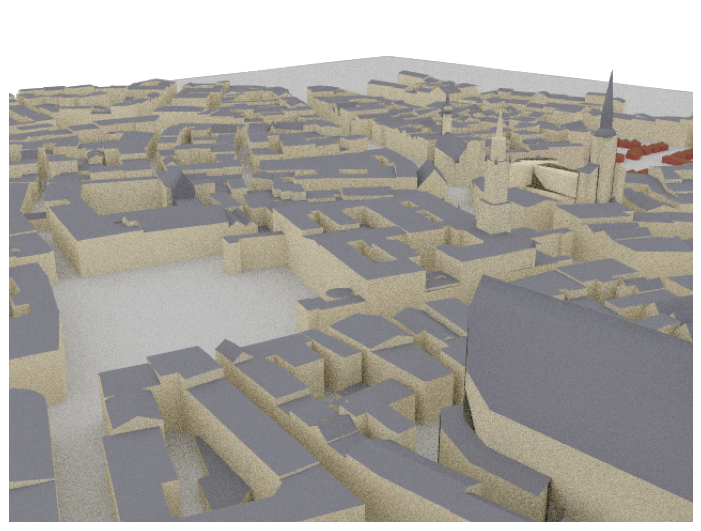

In [2]:
scene = load_scene(sionna.rt.scene.munich)   # objects sharing a material are merged (faster)
print(f"{len(scene.objects)} scene objects, {len(scene.radio_materials)} radio materials")

cam_city = Camera(position=[-250.0, 250.0, 150.0], look_at=[-15.0, 30.0, 28.0])
scene.render(camera=cam_city, resolution=(640, 480), num_samples=32);

In [3]:
def material_table(scene):
    # Print the ITU-R P.2040 parameters of all materials at the current scene frequency
    f = scene.frequency[0]
    print(f"f = {f/1e9:.1f} GHz")
    print(f"{'material':10s} {'eps_r':>7s} {'sigma [S/m]':>12s} {'eta':>22s} {'thickness [m]':>14s}")
    for name, mat in scene.radio_materials.items():
        eps_r, sigma = mat.relative_permittivity[0], mat.conductivity[0]
        eta = eps_r - 1j*sigma/(epsilon_0*2*np.pi*f)
        print(f"{name:10s} {eps_r:7.2f} {sigma:12.3g} {eta.real:9.2f} {eta.imag:+11.3g}j "
              f"{mat.thickness[0]:14.2f}")

material_table(scene)
scene.frequency = 28e9          # the material parameters follow the frequency automatically
print()
material_table(scene)
scene.frequency = 3.5e9

f = 3.5 GHz
material     eps_r  sigma [S/m]                    eta  thickness [m]
marble        7.07       0.0176      7.07     -0.0901j           0.10
metal         1.00        1e+07      1.00   -5.14e+07j           0.10
wood          1.99        0.018      1.99     -0.0924j           0.10
concrete      5.24        0.123      5.24      -0.632j           0.10
brick         3.91       0.0291      3.91      -0.149j           0.10

f = 28.0 GHz
material     eps_r  sigma [S/m]                    eta  thickness [m]
marble        7.07         0.12      7.07     -0.0773j           0.10
metal         1.00        1e+07      1.00   -6.42e+06j           0.10
wood          1.99        0.167      1.99      -0.107j           0.10
concrete      5.24        0.626      5.24      -0.402j           0.10
brick         3.91       0.0406      3.91      -0.026j           0.10


Changing the material of an object is one assignment. Here the walls of the Frauenkirche become
2 cm glass (we will reload a clean scene in the next sections):

In [4]:
church = scene.objects["Frauenkirche-itu_marble"]
print("before:", church.radio_material.name)
church.radio_material = ITURadioMaterial("my-glass", "glass", thickness=0.02)
print("after: ", church.radio_material.name,
      "| eps_r =", round(church.radio_material.relative_permittivity[0], 2))

before: marble
after:  my-glass | eps_r = 6.31


**What we see and why.** The city is modelled with simple extruded buildings: marble walls, metal
roofs, a concrete ground, a few brick and wood objects. Metal has an enormous imaginary part of
$\eta$, so it reflects almost everything ($\lvert\Gamma\rvert\approx 1$); marble and concrete
($\varepsilon_r\approx 5$-$7$) reflect only part of the incident power. The conductivity of the
dielectrics grows with frequency ($\sigma=c\,f^d$). In a low-loss dielectric the attenuation
constant is $\alpha\approx\sigma Z_0/(2\sqrt{\varepsilon_r})$, so the loss inside a marble wall
grows from about 11 dB/m at 3.5 GHz to about 74 dB/m at 28 GHz (the imaginary part of $\eta$
decreases only because $\omega$ grows faster than $\sigma$). Every wall is a 0.1 m slab: keep
this in mind when we discuss transmission through buildings (§12).

> **Instructor notes**
> - **Emphasise:** geometry (no windows, balconies, trees, cars) and material parameters are the largest sources of uncertainty in a ray-tracing study.
> - **Ask the class:** a ray hits a 10 cm marble wall. Is it only reflected?
>   *Expected answer:* no: part of the power is reflected and part is transmitted through the slab with a small loss; since the buildings here are empty shells, a lot of power can cross a whole building (we will see this in §12).
> - **Time:** about 5 min.

## 5. Radio devices: antennas, polarization, frequency

The **antenna pattern** $\mathbf C(\theta,\varphi)=C_\theta\,\hat{\boldsymbol\theta}+C_\varphi\,
\hat{\boldsymbol\varphi}$ contains both the gain and the polarization:
$G(\theta,\varphi)=\lVert\mathbf C(\theta,\varphi)\rVert^2$. All transmitters of a scene use the
same antenna array `scene.tx_array`, and all receivers use `scene.rx_array`. A `PlanarArray` has
a pattern (`"iso"`, `"dipole"`, `"hw_dipole"`, `"tr38901"`) and a polarization (`"V"`, `"H"`,
`"VH"`, `"cross"`). Below: the elevation cut of the four patterns and the directivity and gain
that Sionna computes by numerical integration.

pattern     directivity [dBi]  max gain [dBi]
iso                      0.00            0.00
dipole                   1.76            1.76
hw_dipole                2.15            2.16
tr38901                  9.83            8.00


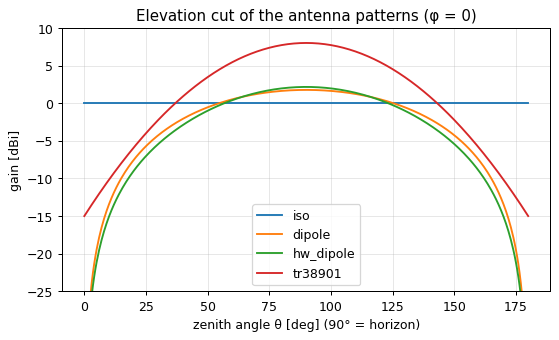

In [5]:
theta = np.linspace(0, np.pi, 361)          # zenith angle: 0 = up, 90 deg = horizon
fig, ax = plt.subplots(figsize=(7, 3.8))
print(f"{'pattern':10s} {'directivity [dBi]':>18s} {'max gain [dBi]':>15s}")
for pattern in ["iso", "dipole", "hw_dipole", "tr38901"]:
    antenna = PlanarArray(num_rows=1, num_cols=1, pattern=pattern, polarization="V").antenna_pattern
    c_theta, c_phi = antenna.patterns[0](mi.Float(theta), mi.Float(np.zeros_like(theta)))
    gain = (dr.abs(c_theta)**2 + dr.abs(c_phi)**2).numpy()
    ax.plot(np.degrees(theta), 10*np.log10(np.maximum(gain, 1e-6)), label=pattern)
    directivity, max_gain, _ = antenna.compute_gain(verbose=False)
    d_dbi = round(10*np.log10(directivity[0]), 2) + 0.0   # "+ 0.0" avoids printing -0.00
    g_dbi = round(10*np.log10(max_gain[0]), 2) + 0.0
    print(f"{pattern:10s} {d_dbi:18.2f} {g_dbi:15.2f}")
ax.set(xlabel="zenith angle θ [deg] (90° = horizon)", ylabel="gain [dBi]", ylim=(-25, 10),
       title="Elevation cut of the antenna patterns (φ = 0)")
ax.legend();

Transmitters and receivers are placed in the scene coordinates (metres, $z$ up). We now build the
scene used in the rest of the lecture: a transmitter on a roof edge, 27 m above the ground, and
two receivers at 1.5 m, one in line of sight (LoS) and one in a street hidden behind a building
(NLoS). All antennas are isotropic and vertically polarized, so the antennas do not hide the
propagation effects.

In [6]:
TX_POS = [8.5, 21.0, 27.0]            # on a roof edge, as in the official Introduction tutorial
RX_LOS_POS = [45.0, 90.0, 1.5]        # in the square, in line of sight
RX_NLOS_POS = [-20.0, 150.0, 1.5]     # in a street behind a building: no line of sight

def make_city_scene(frequency=3.5e9):
    # munich scene with one transmitter (30 dBm) and two receivers, isotropic V antennas
    scene = load_scene(sionna.rt.scene.munich)
    scene.frequency = frequency
    scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
    scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
    scene.add(Transmitter(name="tx", position=TX_POS, power_dbm=30.0))
    scene.add(Receiver(name="rx-los", position=RX_LOS_POS))
    scene.add(Receiver(name="rx-nlos", position=RX_NLOS_POS))
    return scene

scene = make_city_scene()
print("transmitters:", list(scene.transmitters), "| receivers:", list(scene.receivers))
print(f"frequency = {scene.frequency[0]/1e9:.1f} GHz, wavelength = {scene.wavelength[0]*100:.2f} cm")

transmitters: ['tx'] | receivers: ['rx-los', 'rx-nlos']
frequency = 3.5 GHz, wavelength = 8.57 cm


**What we see and why.** The isotropic pattern has 0 dBi in every direction: it is a mathematical
idealisation (no real antenna radiates a single polarization uniformly in all directions), which
is exactly why we use it for validation. The short dipole (1.76 dBi) and the half-wave dipole
(2.15 dBi) give the textbook values. The 3GPP element (`tr38901`) has the 8 dBi maximum gain
specified in TR 38.901; its directivity is 9.8 dB because that pattern is not normalised to
unit radiated power (Sionna reports an efficiency of about 66 %).

> **Instructor notes**
> - **Emphasise:** all transmitters share `scene.tx_array` and all receivers share `scene.rx_array`; positions are in metres in the scene frame.
> - **Ask the class:** why do we use isotropic antennas to validate the ray tracer?
>   *Expected answer:* with $G=1$ in every direction the results can be compared directly with Friis and the two-ray model, without antenna effects.
> - **Time:** about 4 min.

## 6. First paths with `PathSolver`

`PathSolver()(scene, ...)` returns all paths between every transmitter and every receiver. The
main parameters (names and defaults verified for 2.2.0):

| Parameter | Meaning | Default |
|---|---|---|
| `max_depth` | maximum number of interactions per path (0 = line of sight only) | 3 |
| `los` | line-of-sight paths | `True` |
| `specular_reflection` | specular reflections (slab reflection coefficients) | `True` |
| `diffuse_reflection` | diffuse scattering (needs a scattering coefficient > 0) | `False` |
| `refraction` | transmission through objects (thin slabs, no deflection) | `True` |
| `diffraction` | first-order diffraction on wedges (UTD) | `False` |
| `edge_diffraction` | diffraction also on free edges (e.g. the border of a plane) | `False` |
| `samples_per_src` | number of rays shot from each source to find candidates | $10^6$ |
| `seed` | seed of the ray sampling | 42 |

In the city we set `refraction=False` (§12 explains why) and shoot $10^7$ rays per source, ten
times the default: with $10^6$ the NLoS receiver of §8 is not converged (§12 shows the test).

Each path $i$ has a complex coefficient $a_i$ and a delay $\tau_i$; `paths.cir()` returns the
baseband coefficients $a_i e^{-j2\pi f_c\tau_i}$ and the delays, and `paths.interactions` the
type of each interaction (`InteractionType.SPECULAR`, `DIFFRACTION`, `REFRACTION`, `DIFFUSE`).

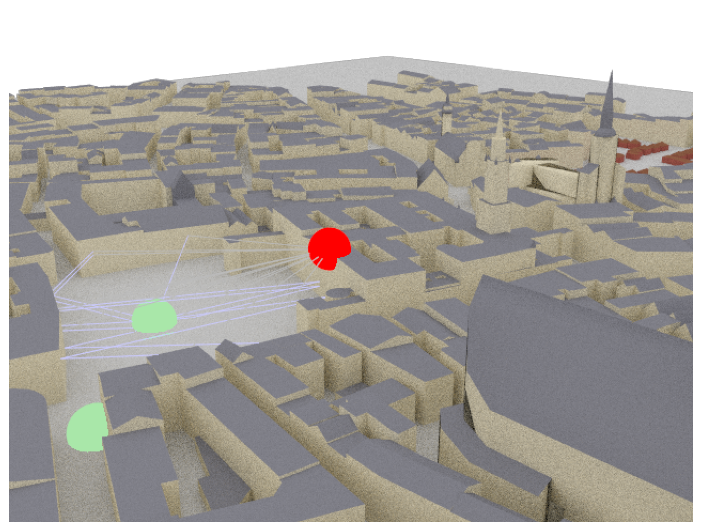

In [7]:
RAYS = 10**7       # rays per source in the city (default 10**6), see §12
solver = PathSolver()
paths = solver(scene, max_depth=3, los=True, specular_reflection=True, diffuse_reflection=False,
               refraction=False, diffraction=False, samples_per_src=RAYS, seed=SEED)
scene.render(camera=cam_city, paths=paths, resolution=(640, 480), num_samples=32);

In [8]:
TYPE_LETTER = {int(InteractionType.SPECULAR): "R", int(InteractionType.DIFFRACTION): "D",
               int(InteractionType.REFRACTION): "T", int(InteractionType.DIFFUSE): "S"}

def path_list(paths, rx):
    # Valid paths of receiver `rx` (one transmitter, single antennas): baseband coefficients,
    # delays [s] and interaction strings such as "R-D" (reflection, then diffraction)
    a, tau = paths.cir(normalize_delays=False, out_type="numpy")
    a, tau = a[rx, 0, 0, 0, :, 0], tau[rx, 0, :]
    valid = paths.valid.numpy()[rx, 0, :]
    inter = paths.interactions.numpy()[:, rx, 0, :]
    types = ["-".join(TYPE_LETTER[int(t)] for t in inter[:, i] if t != 0) or "LoS"
             for i in range(inter.shape[1])]
    keep = np.flatnonzero(valid)
    return a[keep], tau[keep], [types[i] for i in keep]

a, tau, types = path_list(paths, rx=0)
power = np.abs(a)**2
print(f"RX-LoS: {len(a)} paths, total path gain {10*np.log10(power.sum()):.1f} dB")
print(f"{'rank':>4s}  {'interactions':12s} {'delay [ns]':>10s} {'path gain [dB]':>15s}")
for rank, i in enumerate(np.argsort(-power)[:8], start=1):
    print(f"{rank:4d}  {types[i]:12s} {tau[i]*1e9:10.1f} {10*np.log10(power[i]):15.1f}")
print("R = specular reflection, D = diffraction, T = transmission, S = diffuse scattering")

RX-LoS: 11 paths, total path gain -81.1 dB
rank  interactions delay [ns]  path gain [dB]
   1  LoS               273.9           -81.6
   2  R                 524.0           -93.5
   3  R                 592.8           -96.8
   4  R-R               525.7          -102.6
   5  R                 277.2          -104.7
   6  R-R              1029.8          -104.9
   7  R-R-R            1030.7          -109.3
   8  R-R-R            1159.6          -113.1
R = specular reflection, D = diffraction, T = transmission, S = diffuse scattering


How do the number of paths and the total path gain $G=\sum_i\lvert a_i\rvert^2$ change when we
allow more interactions and diffraction?

In [9]:
def total_gain_db(paths, rx):
    a, _, _ = path_list(paths, rx)
    p = np.sum(np.abs(a)**2)
    return (10*np.log10(p) if p > 0 else -np.inf), len(a)

configs = [("LoS only", dict(max_depth=0)),
           ("reflections, max_depth=1", dict(max_depth=1)),
           ("reflections, max_depth=3", dict(max_depth=3)),
           ("reflections, max_depth=5", dict(max_depth=5)),
           ("reflections (5) + diffraction", dict(max_depth=5, diffraction=True))]
print(f"{'configuration':31s} {'RX-LoS: paths':>14s} {'G [dB]':>8s} {'RX-NLoS: paths':>15s} {'G [dB]':>8s}")
for label, kwargs in configs:
    p = solver(scene, refraction=False, samples_per_src=RAYS, seed=SEED, **kwargs)
    (g_los, n_los), (g_nlos, n_nlos) = total_gain_db(p, 0), total_gain_db(p, 1)
    print(f"{label:31s} {n_los:14d} {g_los:8.1f} {n_nlos:15d} {g_nlos:8.1f}")

configuration                    RX-LoS: paths   G [dB]  RX-NLoS: paths   G [dB]


LoS only                                     1    -81.6               0     -inf


reflections, max_depth=1                     4    -81.2               0     -inf
reflections, max_depth=3                    11    -81.1               0     -inf


reflections, max_depth=5                    14    -81.1               1   -151.0


reflections (5) + diffraction              578    -81.1             182   -107.8


**What we see and why.** At RX-LoS the line-of-sight path carries most of the power: allowing
more reflections and diffraction raises the number of paths from 1 to several hundred but changes
$G$ by only 0.5 dB, because every reflection loses power ($\lvert\Gamma\rvert<1$) and reflected
paths are longer. At RX-NLoS there is no path with line of sight only, and none with up to three
reflections; with five reflections a single, very weak path appears (about $-151$ dB). Diffraction
around the building corners raises $G$ to about $-108$ dB, more than 40 dB higher: at this
receiver diffraction is the dominant mechanism. The number of paths grows quickly with
`max_depth` and with diffraction, and so does the cost.

> **Instructor notes**
> - **Emphasise:** the parameter names and their defaults (refraction is on by default); `max_depth` is a trade-off between accuracy and cost.
> - **Ask the class:** why does the path gain at RX-LoS hardly change while the number of paths grows from a handful to hundreds?
>   *Expected answer:* the LoS path dominates; each extra interaction loses power and lengthens the path, so the new paths are much weaker.
> - **Time:** about 6 min.

## 7. Physical validation

### 7a. Free space: Friis

With isotropic antennas, the path gain of the LoS path at distance $d$ is
$$G_\mathrm{FS}=\left(\frac{\lambda}{4\pi d}\right)^2,\qquad
G_\mathrm{FS,dB}=-20\log_{10}\frac{4\pi d}{\lambda},$$
a slope of $-20$ dB per decade (path-loss exponent $n=2$). We place receivers from 1 m to 5 km
in an empty scene and compare.

largest |RT - Friis| = 7.6e-06 dB


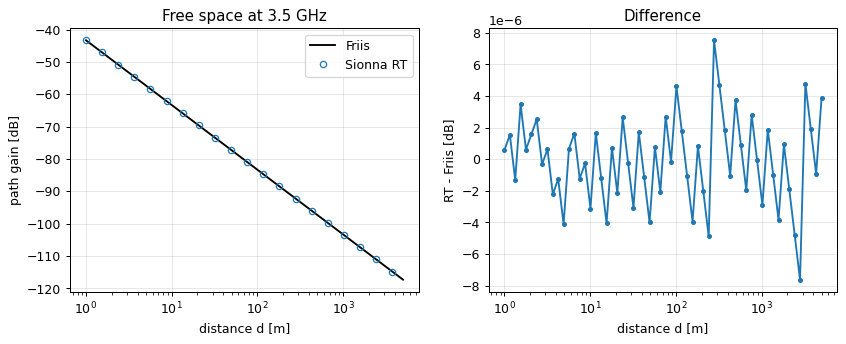

In [10]:
f0 = 3.5e9
lam0 = speed_of_light/f0
scene_fs = load_scene()                     # empty scene: free space
scene_fs.frequency = f0
scene_fs.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene_fs.rx_array = scene_fs.tx_array
scene_fs.add(Transmitter(name="tx", position=[0.0, 0.0, 10.0]))
d = np.logspace(0, np.log10(5000), 60)     # 1 m ... 5 km
for i, di in enumerate(d):
    scene_fs.add(Receiver(name=f"rx{i}", position=[float(di), 0.0, 10.0]))

paths_fs = PathSolver()(scene_fs, max_depth=0, seed=SEED)
a_fs, _ = paths_fs.cir(out_type="numpy")
g_rt_db = 10*np.log10(np.abs(a_fs[:, 0, 0, 0, 0, 0])**2)
g_friis_db = 20*np.log10(lam0/(4*np.pi*d))
err = g_rt_db - g_friis_db
print(f"largest |RT - Friis| = {np.max(np.abs(err)):.1e} dB")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.semilogx(d, g_friis_db, "k-", label="Friis")
ax1.semilogx(d[::3], g_rt_db[::3], "o", ms=5, mfc="none", label="Sionna RT")
ax1.set(xlabel="distance d [m]", ylabel="path gain [dB]", title="Free space at 3.5 GHz")
ax1.legend()
ax2.semilogx(d, err, ".-")
ax2.set(xlabel="distance d [m]", ylabel="RT - Friis [dB]", title="Difference")
ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0));

**What we see and why.** The two curves coincide: the difference is of the order of $10^{-5}$ dB,
i.e. single-precision rounding. The ray tracer computes the LoS field as a spherical wave
$e^{-jkd}/d$ weighted by the antenna patterns, so Friis is built into it.

### 7b. The two-ray model over a real ground

A transmitter at height $h_t$ and a receiver at height $h_r$, at horizontal distance $d$ over a
flat ground, receive the direct ray (length $r_1$) and the ray reflected by the ground (length
$r_2$, angle of incidence $\theta_i$ measured from the normal):
$$G=\left(\frac{\lambda}{4\pi}\right)^2\left|\frac{e^{-jkr_1}}{r_1}+R(\theta_i)\,
\frac{e^{-jkr_2}}{r_2}\right|^2,\qquad r_{1,2}=\sqrt{d^2+(h_t\mp h_r)^2},\qquad
\cos\theta_i=\frac{h_t+h_r}{r_2}.$$
Sionna uses the ITU-R P.2040 convention for the Fresnel coefficients of a half-space with complex
relative permittivity $\eta$:
$$r_\perp=\frac{\cos\theta_i-\sqrt{\eta-\sin^2\theta_i}}{\cos\theta_i+\sqrt{\eta-\sin^2\theta_i}}
\ \ (\text{TE}),\qquad
r_\parallel=\frac{\eta\cos\theta_i-\sqrt{\eta-\sin^2\theta_i}}{\eta\cos\theta_i+\sqrt{\eta-\sin^2\theta_i}}
\ \ (\text{TM}).$$
Textbooks differ in the sign convention of $r_\parallel$: always check it before comparing. Here
we use **horizontally polarized** antennas: the electric field is perpendicular to the plane of
incidence, so the TE coefficient $r_\perp$ applies. (The vertical case is in the lab.)

For $d\gg h_t,h_r$: $R\to-1$ (grazing incidence) and the phase difference
$k(r_2-r_1)\approx 4\pi h_th_r/(\lambda d)$ goes to zero, so the two rays cancel more and more.
Beyond the **breakpoint distance** $d_b=4h_th_r/\lambda$:
$$G\approx\left(\frac{h_th_r}{d^2}\right)^2\qquad(\text{path-loss exponent } n=4,
\text{ independent of frequency}).$$

**Building the ground.** We build a flat ground of 100 m × 100 m tiles (ITU *medium dry ground*,
3.5 GHz), with a **1 m thick** slab so that its reflection coefficient equals that of a
half-space. A single huge triangle would be simpler, but we found that with one 4 km triangle
some reflections are lost because of single-precision errors in the path validation.

In [11]:
def flat_ground(x_min, x_max, y_min, y_max, tile=100.0):
    # Flat ground at z = 0 made of square tiles (two triangles each), as a Mitsuba mesh
    xs = np.arange(x_min, x_max + tile/2, tile)
    ys = np.arange(y_min, y_max + tile/2, tile)
    X, Y = np.meshgrid(xs, ys, indexing="ij")
    vertices = np.stack([X.ravel(), Y.ravel(), np.zeros(X.size)], axis=1)
    ny = len(ys)
    faces = []
    for i in range(len(xs) - 1):
        for j in range(ny - 1):
            v0, v1, v2, v3 = i*ny + j, (i+1)*ny + j, (i+1)*ny + j + 1, i*ny + j + 1
            faces += [[v0, v1, v2], [v0, v2, v3]]          # counter-clockwise: normal along +z
    faces = np.array(faces)
    mesh = mi.Mesh("ground", vertex_count=len(vertices), face_count=len(faces),
                   has_vertex_normals=False, has_vertex_texcoords=False)
    params = mi.traverse(mesh)
    params["vertex_positions"] = mi.Float(vertices.ravel().astype(np.float32))
    params["faces"] = mi.UInt32(faces.ravel().astype(np.uint32))
    params.update()
    return mesh

h_t, h_r = 5.0, 1.5                          # antenna heights [m]
ground_mat = ITURadioMaterial("ground-mat", "medium_dry_ground", thickness=1.0)
scene_2r = load_scene()
scene_2r.edit(add=[SceneObject(mi_mesh=flat_ground(-50.0, 2050.0, -100.0, 100.0),
                               name="ground", radio_material=ground_mat)])
scene_2r.frequency = f0
scene_2r.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="H")
scene_2r.rx_array = scene_2r.tx_array
scene_2r.add(Transmitter(name="tx", position=[0.0, 0.0, h_t]))
d2 = np.logspace(1, np.log10(2000), 300)    # 10 m ... 2 km
for i, di in enumerate(d2):
    scene_2r.add(Receiver(name=f"rx{i}", position=[float(di), 0.0, h_r]))

paths_2r = PathSolver()(scene_2r, max_depth=1, los=True, specular_reflection=True,
                        refraction=False, seed=SEED)
a_2r, _ = paths_2r.cir(out_type="numpy")
g_rt = np.abs(a_2r[:, 0, 0, 0, :, 0].sum(axis=-1))**2   # coherent sum: LoS + ground reflection
print("paths per receiver:", np.unique(paths_2r.valid.numpy().reshape(len(d2), -1).sum(axis=-1)))

paths per receiver: [2]


eta of medium dry ground at 3.5 GHz: 13.23 -1.39j
breakpoint distance d_b = 4 h_t h_r / lambda = 350 m
|RT - two-ray| away from nulls, 10-300 m: max 0.024 dB
|RT - two-ray| away from nulls, 300-2000 m: max 0.165 dB


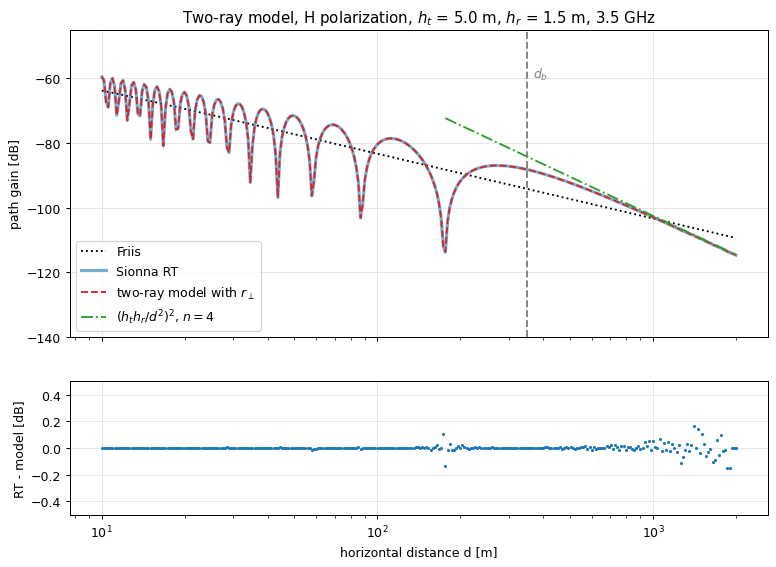

In [12]:
eta_g = ground_mat.relative_permittivity[0] - 1j*ground_mat.conductivity[0]/(epsilon_0*2*np.pi*f0)
r1 = np.sqrt(d2**2 + (h_t - h_r)**2)
r2 = np.sqrt(d2**2 + (h_t + h_r)**2)
cos_i = (h_t + h_r)/r2
root = np.sqrt(eta_g - (1 - cos_i**2))
r_perp = (cos_i - root)/(cos_i + root)       # TE coefficient: horizontal polarization
k0 = 2*np.pi/lam0
g_2ray = (lam0/(4*np.pi))**2*np.abs(np.exp(-1j*k0*r1)/r1 + r_perp*np.exp(-1j*k0*r2)/r2)**2
g_fs = (lam0/(4*np.pi*r1))**2
d_b = 4*h_t*h_r/lam0
err_2r = 10*np.log10(g_rt/g_2ray)
away = g_2ray > g_fs/10                      # away from the deep interference nulls
print(f"eta of medium dry ground at 3.5 GHz: {eta_g.real:.2f} {eta_g.imag:+.2f}j")
print(f"breakpoint distance d_b = 4 h_t h_r / lambda = {d_b:.0f} m")
for lo, hi in [(10, 300), (300, 2000)]:
    sel = away & (d2 >= lo) & (d2 < hi)
    print(f"|RT - two-ray| away from nulls, {lo}-{hi} m: max {np.max(np.abs(err_2r[sel])):.3f} dB")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True, height_ratios=[3, 1.3])
ax1.semilogx(d2, 10*np.log10(g_fs), "k:", label="Friis")
ax1.semilogx(d2, 10*np.log10(g_rt), "-", lw=2.5, alpha=0.6, label="Sionna RT")
ax1.semilogx(d2, 10*np.log10(g_2ray), "--", color="C3", label=r"two-ray model with $r_\perp$")
d_far = d2[d2 > d_b/2]
ax1.semilogx(d_far, 10*np.log10((h_t*h_r/d_far**2)**2), "-.", color="C2",
             label=r"$(h_t h_r/d^2)^2$, $n=4$")
ax1.axvline(d_b, color="gray", ls="--")
ax1.text(d_b*1.05, -60, r"$d_b$", color="gray")
ax1.set(ylabel="path gain [dB]", ylim=(-140, -45),
        title=f"Two-ray model, H polarization, $h_t$ = {h_t} m, $h_r$ = {h_r} m, 3.5 GHz")
ax1.legend(loc="lower left")
ax2.semilogx(d2, err_2r, ".", ms=3)
ax2.set(xlabel="horizontal distance d [m]", ylabel="RT - model [dB]", ylim=(-0.5, 0.5));

Why a **1 m** thick ground? Sionna's slab coefficient is
$r=r'\,(1-e^{-j2q})/(1-r'^2e^{-j2q})$ with $q=\frac{2\pi t}{\lambda}\sqrt{\eta-\sin^2\theta_i}$
(ITU-R P.2040), where $t$ is the thickness and $r'$ the half-space coefficient. In a thick lossy slab the wave
reflected by the back face dies out ($e^{-j2q}\to 0$) and $r\to r'$; in a thin slab it interferes.

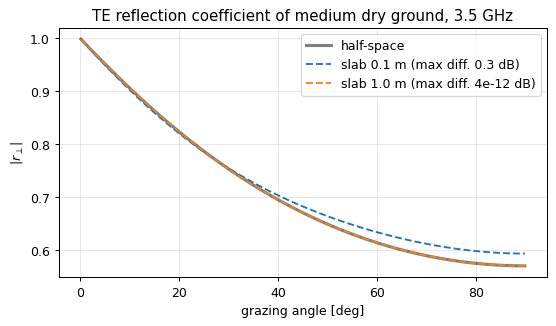

In [13]:
psi = np.radians(np.linspace(0.2, 89.8, 500))      # grazing angle = 90 deg - theta_i
cos_i_g = np.sin(psi)
root_g = np.sqrt(eta_g - (1 - cos_i_g**2))
r_half = (cos_i_g - root_g)/(cos_i_g + root_g)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(np.degrees(psi), np.abs(r_half), "k-", lw=2.5, alpha=0.5, label="half-space")
for thickness in [0.1, 1.0]:
    q = 2*np.pi*thickness/lam0*root_g
    r_slab = r_half*(1 - np.exp(-2j*q))/(1 - r_half**2*np.exp(-2j*q))
    diff = np.max(np.abs(20*np.log10(np.abs(r_slab/r_half))))
    ax.plot(np.degrees(psi), np.abs(r_slab), "--", label=f"slab {thickness} m (max diff. {diff:.1g} dB)")
ax.set(xlabel="grazing angle [deg]", ylabel=r"$|r_\perp|$",
       title="TE reflection coefficient of medium dry ground, 3.5 GHz")
ax.legend();

**What we see and why.** Ray tracing and the analytical two-ray model coincide. Away from the
deep nulls the difference is at most a few hundredths of a dB up to 300 m and below 0.2 dB up to
2 km: it grows with distance because there the two rays almost cancel and the single-precision
rounding of the path lengths becomes visible (near a null any tiny difference looks large in dB).
Before the breakpoint ($d_b\approx 350$ m) the reflected ray interferes alternately
constructively and destructively as the path difference changes by $\lambda$: a few dB above
Friis (at most +6 dB if $\lvert R\rvert=1$) or deep nulls. Beyond $d_b$ the curve follows
$(h_th_r/d^2)^2$, a slope of $-40$ dB per decade. The ray tracer simply applies the Fresnel
coefficient we know, but the details matter: polarization, sign convention, and the **thickness
of the slab**. For this lossy ground a 0.1 m slab would change $\lvert r_\perp\rvert$ by up to
0.3 dB; for a low-loss 0.1 m wall the difference reaches more than 10 dB at some angles.

> **Instructor notes**
> - **Emphasise:** 'the ray tracer applies the theory you know': Friis and Fresnel are built in. Agreement requires the same assumptions on both sides (polarization, convention, slab thickness, float32 precision).
> - **Ask the class:** beyond the breakpoint the path gain does not depend on frequency. Why?
>   *Expected answer:* $G\approx(h_th_r/d^2)^2$: the $\lambda^2$ of the isotropic aperture cancels with the $1/\lambda^2$ of the squared phase difference $(4\pi h_th_r/\lambda d)^2$.
> - **Time:** about 9 min.

## 8. From paths to the channel

The paths give the **channel impulse response** (CIR) and, from it, the usual small-scale
parameters:
$$h(\tau)=\sum_i a_i\,e^{-j2\pi f_c\tau_i}\,\delta(\tau-\tau_i),\qquad
P_i=\lvert a_i\rvert^2\ \ (\text{power delay profile, PDP}),$$
$$\bar\tau=\frac{\sum_iP_i\tau_i}{\sum_iP_i},\qquad
\tau_\mathrm{rms}=\sqrt{\frac{\sum_iP_i\tau_i^2}{\sum_iP_i}-\bar\tau^2},\qquad
H(f)=\sum_i a_i\,e^{-j2\pi f_c\tau_i}e^{-j2\pi f\tau_i}.$$
The frequency correlation of the channel is the Fourier transform of the PDP,
$R(\Delta f)=\sum_iP_ie^{-j2\pi\Delta f\tau_i}/\sum_iP_i$, and the coherence bandwidth $B_c$ is
the $\Delta f$ where $\lvert R\rvert$ drops to 0.5; a common rule of thumb is
$B_c\approx 1/(5\,\tau_\mathrm{rms})$. With a LoS path we also compute the Rice factor
$K=P_\mathrm{LoS}/\sum_{i\ne\mathrm{LoS}}P_i$.

We trace the two receivers with up to 5 reflections and diffraction.

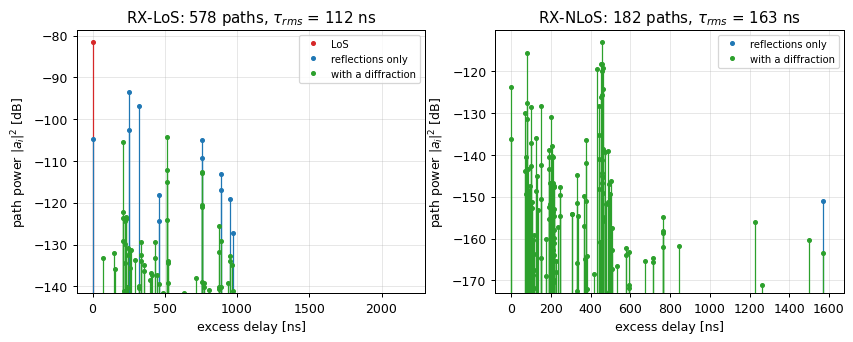

In [14]:
scene = make_city_scene()
paths = solver(scene, max_depth=5, diffraction=True, refraction=False, samples_per_src=RAYS, seed=SEED)

def delay_stats(tau, p):
    # Mean excess delay and RMS delay spread [s] of a discrete power delay profile
    tau = tau - tau.min()
    tau_mean = np.sum(p*tau)/np.sum(p)
    return tau_mean, np.sqrt(np.sum(p*(tau - tau_mean)**2)/np.sum(p))

classes = [("LoS", lambda t: t == "LoS", "C3"),
           ("reflections only", lambda t: t != "LoS" and "D" not in t, "C0"),
           ("with a diffraction", lambda t: "D" in t, "C2")]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, rx, name in zip(axes, [0, 1], ["RX-LoS", "RX-NLoS"]):
    a, tau, types = path_list(paths, rx)
    p = np.abs(a)**2
    p_db, tau_ns = 10*np.log10(p), (tau - tau.min())*1e9
    for label, select, color in classes:
        sel = np.array([select(t) for t in types])
        if sel.any():
            ax.vlines(tau_ns[sel], p_db.max() - 60, p_db[sel], color=color, lw=1)
            ax.plot(tau_ns[sel], p_db[sel], "o", ms=3, color=color, label=label)
    tau_mean, tau_rms = delay_stats(tau, p)
    ax.set(xlabel="excess delay [ns]", ylabel="path power $|a_i|^2$ [dB]",
           ylim=(p_db.max() - 60, p_db.max() + 3),
           title=f"{name}: {len(a)} paths, $\\tau_{{rms}}$ = {tau_rms*1e9:.0f} ns")
    ax.legend(fontsize=8)

          G [dB]  mean delay [ns]  tau_rms [ns]  K [dB]  1/(5 tau_rms) [MHz]   first dip of |R|  first |R|<0.5 [MHz]
RX-LoS     -81.1             35.6         111.9     8.9                 1.79    0.80 at 1.87 MHz                  nan
RX-NLoS   -107.8            363.4         163.4     nan                 1.22    0.52 at 1.32 MHz                 9.23


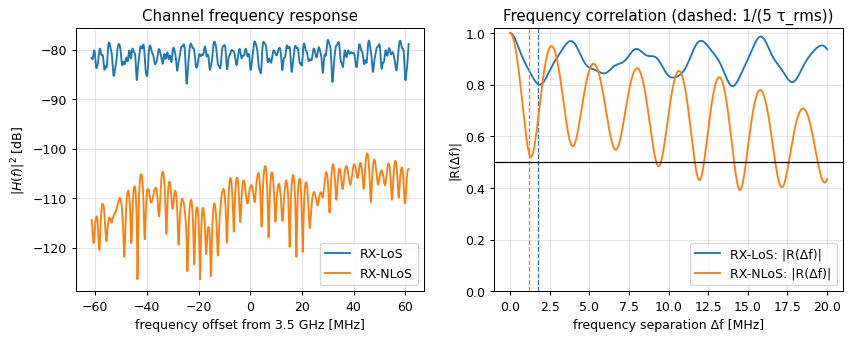

In [15]:
freqs = subcarrier_frequencies(1024, 120e3)            # 1024 x 120 kHz = 123 MHz around f_c
h_f = paths.cfr(frequencies=freqs, normalize_delays=True, out_type="numpy")[:, 0, 0, 0, 0, :]
f_mhz = freqs.numpy()/1e6
delta_f = np.linspace(0, 20e6, 2001)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
print(f"{'':8s} {'G [dB]':>7s} {'mean delay [ns]':>16s} {'tau_rms [ns]':>13s} {'K [dB]':>7s} "
      f"{'1/(5 tau_rms) [MHz]':>20s} {'first dip of |R|':>18s} {'first |R|<0.5 [MHz]':>20s}")
for rx, name, color in [(0, "RX-LoS", "C0"), (1, "RX-NLoS", "C1")]:
    a, tau, types = path_list(paths, rx)
    p = np.abs(a)**2
    tau_mean, tau_rms = delay_stats(tau, p)
    los = np.array([t == "LoS" for t in types])
    k_db = 10*np.log10(p[los].sum()/p[~los].sum()) if los.any() else np.nan
    corr = np.abs(np.exp(-2j*np.pi*np.outer(delta_f, tau - tau.min())) @ p)/p.sum()
    b_c = delta_f[np.argmax(corr < 0.5)] if np.any(corr < 0.5) else np.nan
    i_dip = next((i for i in range(1, len(corr) - 1) if corr[i] <= corr[i-1] and corr[i] < corr[i+1]),
                 len(corr) - 1)                         # first local minimum of |R|
    print(f"{name:8s} {10*np.log10(p.sum()):7.1f} {tau_mean*1e9:16.1f} {tau_rms*1e9:13.1f} {k_db:7.1f} "
          f"{1/(5*tau_rms)/1e6:20.2f} {corr[i_dip]:7.2f} at {delta_f[i_dip]/1e6:4.2f} MHz "
          f"{b_c/1e6:20.2f}")
    ax1.plot(f_mhz, 20*np.log10(np.abs(h_f[rx])), color=color, label=name)
    ax2.plot(delta_f/1e6, corr, color=color, label=f"{name}: |R(Δf)|")
    ax2.axvline(1/(5*tau_rms)/1e6, color=color, ls="--", lw=1)
ax1.set(xlabel="frequency offset from 3.5 GHz [MHz]", ylabel="$|H(f)|^2$ [dB]",
        title="Channel frequency response")
ax1.legend()
ax2.axhline(0.5, color="k", lw=1)
ax2.set(xlabel="frequency separation Δf [MHz]", ylabel="|R(Δf)|", ylim=(0, 1.02),
        title="Frequency correlation (dashed: 1/(5 τ_rms))")
ax2.legend();

**What we see and why.**
- **RX-LoS:** a dominant LoS path (Rice factor of about 9 dB) followed by weaker reflections.
  $\tau_\mathrm{rms}\approx 110$ ns is set mostly by a few weak but late reflections, because the
  delay enters squared. The frequency response is nearly flat and $\lvert R(\Delta f)\rvert$ never
  drops to 0.5: with $K$ in linear scale, $\lvert R\rvert\ge (K-1)/(K+1)\approx 0.77$. The rule of
  thumb $1/(5\tau_\mathrm{rms})$ is meaningless for such a Rician channel.
- **RX-NLoS:** no dominant path, many comparable diffracted paths, $\tau_\mathrm{rms}\approx 160$ ns
  and deep frequency-selective fades. $\lvert R\rvert$ first drops to about 0.5 at
  $\Delta f\approx 1.3$ MHz, close to $1/(5\tau_\mathrm{rms})\approx 1.2$ MHz, but then rises again
  and oscillates with a period of about 2.6 MHz: the power arrives in two groups of paths, around
  80 ns and 455 ns of excess delay (see the PDP), and $\lvert R\rvert$ is the Fourier transform of
  the PDP: $1/(380\ \mathrm{ns})\approx 2.6$ MHz. The strict
  definition "first $\Delta f$ with $\lvert R\rvert<0.5$" therefore jumps to about 9 MHz. The
  coherence bandwidth is an order of magnitude, not a precise number, for a clustered
  site-specific channel.
- For comparison, 3GPP TR 38.901 (V19.5.0) gives for the urban macro scenario at 3.5 GHz median
  delay spreads of 74 ns (LoS) and 267 ns (NLoS), with a large log-normal spread, and a mean
  K-factor of 9 dB in LoS: our site-specific values are of the same order.

> **Instructor notes**
> - **Emphasise:** the chain PDP → $\tau_\mathrm{rms}$ → $B_c$, and that the rule of thumb assumes no dominant path.
> - **Ask the class:** what happens to $\tau_\mathrm{rms}$ at RX-LoS if we ignore all paths more than 30 dB below the strongest one, as a measurement system with 30 dB dynamic range would?
>   *Expected answer:* it decreases (here only 9 of almost 600 paths are within 30 dB of the strongest, and $\tau_\mathrm{rms}$ drops from about 112 to 103 ns; with 20 dB, to about 77 ns): weak but late paths weigh a lot in the second moment ($\tau_i^2$), so measured delay spreads depend on the dynamic range.
> - **Time:** about 8 min.

## 9. Radio maps

A **radio map** gives, for every cell $C_i$ of a surface (here a horizontal plane at 1.5 m), the
average path gain
$$g_i=\frac{1}{\lvert C_i\rvert}\int_{C_i}\sum_j\lvert a_j(s)\rvert^2\,ds$$
for an ideal isotropic receiver. The powers of the paths are added **non-coherently**, so a radio
map shows the local average (no fast fading). `RadioMapSolver` estimates $g_i$ by shooting rays
(SBR, Monte Carlo): more rays give less noise. Multiplied by the transmit power, $g_i$ gives the
received signal strength `rm.rss` (in W).

We compute maps of 500 m × 500 m around the transmitter, with 2 m cells and $10^7$ rays, for an
increasing number of interactions, with diffraction, and with diffuse scattering.

In [16]:
def outdoor_mask(scene, rm, z=1.5):
    # True for the cells that have no building above them (vertical ray cast from above the scene)
    centers = rm.cell_centers.numpy().reshape(-1, 3)
    z_top = float(scene.mi_scene.bbox().max.z) + 10.0
    origins = mi.Point3f(centers[:, 0], centers[:, 1], np.full(len(centers), z_top, dtype=np.float32))
    hit = scene.mi_scene.ray_intersect(mi.Ray3f(origins, mi.Vector3f(0.0, 0.0, -1.0)))
    return (hit.t.numpy() >= z_top - z).reshape(rm.cell_centers.shape[:2])

rm_solver = RadioMapSolver()
MAP_ARGS = dict(center=[TX_POS[0], TX_POS[1], 1.5], orientation=[0.0, 0.0, 0.0],
                size=[500.0, 500.0], cell_size=[2.0, 2.0], samples_per_tx=10**7,
                refraction=False, seed=SEED)
radio_maps = {}
for label, kwargs in [("LoS only (max_depth=0)", dict(max_depth=0)),
                      ("max_depth=1", dict(max_depth=1)),
                      ("max_depth=3", dict(max_depth=3)),
                      ("max_depth=5", dict(max_depth=5)),
                      ("max_depth=5 + diffraction", dict(max_depth=5, diffraction=True))]:
    radio_maps[label] = rm_solver(scene, **MAP_ARGS, **kwargs)

# Diffuse scattering: give every material a scattering coefficient S = 0.3 (default: S = 0)
for mat in scene.radio_materials.values():
    mat.scattering_coefficient = 0.3
radio_maps["max_depth=5 + scattering (S=0.3)"] = rm_solver(scene, **MAP_ARGS, max_depth=5,
                                                           diffuse_reflection=True)
for mat in scene.radio_materials.values():
    mat.scattering_coefficient = 0.0

outdoor cells: 46.8 % of the map


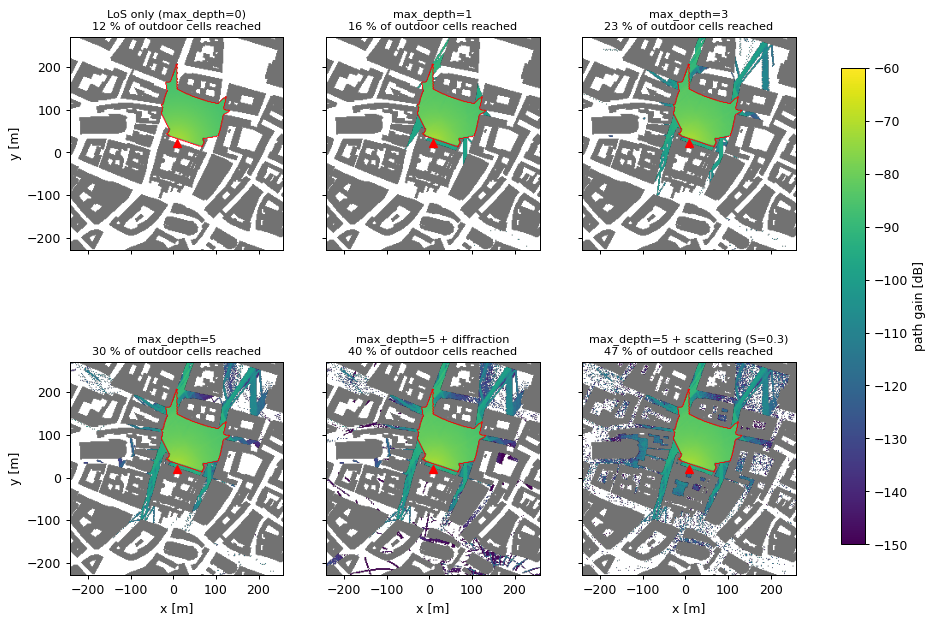

In [17]:
rm0 = radio_maps["LoS only (max_depth=0)"]
outdoor = outdoor_mask(scene, rm0)
centers = rm0.cell_centers.numpy()
extent = [centers[0, 0, 0] - 1, centers[0, -1, 0] + 1, centers[0, 0, 1] - 1, centers[-1, 0, 1] + 1]
los_cells = rm0.path_gain.numpy()[0] > 0

def show_map(ax, g, title, vmin=-150, vmax=-60):
    g_db = np.where(g > 0, 10*np.log10(np.where(g > 0, g, 1.0)), np.nan)
    im = ax.imshow(g_db, origin="lower", extent=extent, vmin=vmin, vmax=vmax, cmap="viridis")
    ax.imshow(np.where(outdoor, np.nan, 1.0), origin="lower", extent=extent, cmap="Greys",
              vmin=0, vmax=1.6)                                     # buildings in grey
    ax.contour(centers[..., 0], centers[..., 1], los_cells.astype(float), levels=[0.5], colors="red",
               linewidths=0.7)
    ax.plot(TX_POS[0], TX_POS[1], "r^", ms=7)
    ax.set_title(title, fontsize=9)
    ax.grid(False)
    return im

print(f"outdoor cells: {outdoor.mean()*100:.1f} % of the map")
fig, axes = plt.subplots(2, 3, figsize=(13, 8.6), sharex=True, sharey=True)
for ax, (label, rm) in zip(axes.ravel(), radio_maps.items()):
    g = rm.path_gain.numpy()[0]
    im = show_map(ax, g, f"{label}\n{np.mean(g[outdoor] > 0)*100:.0f} % of outdoor cells reached")
for ax in axes[1]:
    ax.set_xlabel("x [m]")
for ax in axes[:, 0]:
    ax.set_ylabel("y [m]")
fig.colorbar(im, ax=axes, shrink=0.8, label="path gain [dB]");

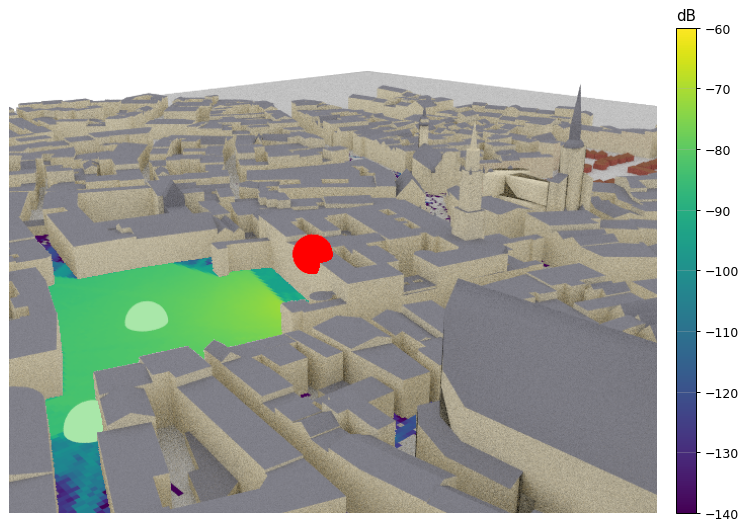

In [18]:
scene.render(camera=cam_city, radio_map=radio_maps["max_depth=5 + diffraction"], rm_vmin=-140,
             rm_vmax=-60, rm_show_color_bar=True, resolution=(640, 480), num_samples=32);

*(Optional)* The same map seen as a path-gain-vs-distance scatter, compared with the 3GPP
TR 38.901 urban macro (UMa) path-loss formulas at 3.5 GHz ($h_\mathrm{UT}$ = 1.5 m,
$d$ in m, $f_c$ in GHz, valid below the breakpoint, which is about 600 m here):
$\mathrm{PL_{LoS}}=28.0+22\log_{10}d_\mathrm{3D}+20\log_{10}f_c$,
$\mathrm{PL_{NLoS}}=\max\!\left(\mathrm{PL_{LoS}},\,13.54+39.08\log_{10}d_\mathrm{3D}+20\log_{10}f_c\right)$,
with shadow-fading standard deviations of 4 dB (LoS) and 6 dB (NLoS).

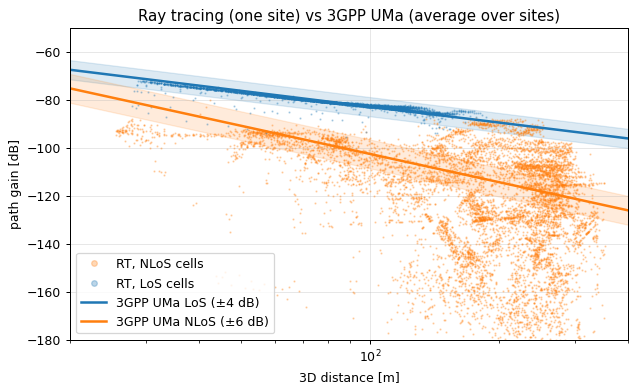

In [19]:
g = radio_maps["max_depth=5 + diffraction"].path_gain.numpy()[0]
d3d = np.sqrt((centers[..., 0] - TX_POS[0])**2 + (centers[..., 1] - TX_POS[1])**2 + (1.5 - TX_POS[2])**2)
reached = outdoor & (g > 0)
dd = np.logspace(np.log10(20), np.log10(400), 100)
pl_los = 28.0 + 22*np.log10(dd) + 20*np.log10(3.5)
pl_nlos = np.maximum(pl_los, 13.54 + 39.08*np.log10(dd) + 20*np.log10(3.5))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(d3d[reached & ~los_cells], 10*np.log10(g[reached & ~los_cells]), ".", ms=1.5,
            color="C1", alpha=0.3, label="RT, NLoS cells")
ax.semilogx(d3d[reached & los_cells], 10*np.log10(g[reached & los_cells]), ".", ms=1.5,
            color="C0", alpha=0.3, label="RT, LoS cells")
ax.semilogx(dd, -pl_los, "C0-", lw=2, label="3GPP UMa LoS (±4 dB)")
ax.fill_between(dd, -pl_los - 4, -pl_los + 4, color="C0", alpha=0.15)
ax.semilogx(dd, -pl_nlos, "C1-", lw=2, label="3GPP UMa NLoS (±6 dB)")
ax.fill_between(dd, -pl_nlos - 6, -pl_nlos + 6, color="C1", alpha=0.15)
ax.set(xlabel="3D distance [m]", ylabel="path gain [dB]", ylim=(-180, -50), xlim=(20, 400),
       title="Ray tracing (one site) vs 3GPP UMa (average over sites)")
ax.legend(loc="lower left", markerscale=6);

**What we see and why.**
- **Max depth.** With LoS only, the signal exists only where the transmitter is visible (red
  contour). Each additional reflection carries power further along the streets (street canyons
  act as waveguides): the reached outdoor area grows from 12 % (LoS only) to 30 % (up to five
  reflections).
- **Diffraction.** It fills the shadow regions just behind building corners with weak power
  (mostly below $-120$ dB): the reached outdoor area grows from 30 % to 40 %. Enclosed courtyards
  stay dark: reaching them would need several diffractions (Sionna allows one per path) or
  transmission through buildings.
- **Diffuse scattering.** It spreads weak power into many more cells (the speckled pattern is the
  Monte Carlo noise of the scattered field) and slightly reduces the specular reflections,
  because a fraction $S^2$ of the reflected energy is scattered.
- **3GPP comparison (optional).** In LoS the ray tracer follows the 3GPP LoS formula, which is
  close to free space here. In NLoS the ray-traced values spread over tens of dB around the 3GPP
  curve: this is the site-specific shadowing that a stochastic model only describes statistically.
  Cells reached by no ray are not plotted, so the scatter is biased towards stronger values.

> **Instructor notes**
> - **Emphasise:** a radio map is a local average (non-coherent sum of path powers); paths at one point (§8) give the coherent channel. A whole map takes about a second on a GPU.
> - **Ask the class:** why do the radio maps not show the interference ripples we saw in the two-ray model?
>   *Expected answer:* the map adds the path powers non-coherently and averages them over each 2 m cell; the ripples (fast fading) only appear in the coherent sum at a given point.
> - **Time:** about 7 min.

## 10. Parametric study: frequency and materials

**Frequency.** With isotropic antennas $G\propto\lambda^2$ (effective aperture
$\lambda^2/4\pi$), so going from 3.5 to 28 GHz lowers every path by
$20\log_{10}(28/3.5)=18.06$ dB, plus the change of the material parameters. Diffraction
coefficients also scale as $1/\sqrt{k}$: far from the shadow boundaries a diffracted path loses
up to $10\log_{10}(28/3.5)\approx 9$ dB more than a specular one.

          G at 3.5 GHz  G at 28 GHz  difference   (aperture effect: -18.06 dB)
RX-LoS        -81.1 dB     -99.0 dB    -17.9 dB
RX-NLoS      -107.8 dB    -128.2 dB    -20.4 dB
outdoor cells reached at 3.5 GHz: 39.8 %, at 28 GHz: 39.6 %


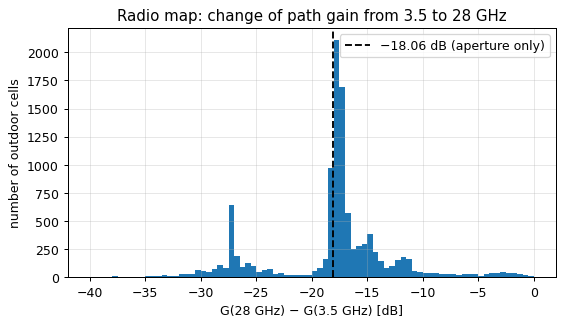

In [20]:
scene = make_city_scene()
gains, maps_f = {}, {}
for fc in [3.5e9, 28e9]:
    scene.frequency = fc
    p = solver(scene, max_depth=5, diffraction=True, refraction=False, samples_per_src=RAYS, seed=SEED)
    gains[fc] = [total_gain_db(p, rx)[0] for rx in (0, 1)]
    maps_f[fc] = rm_solver(scene, **MAP_ARGS, max_depth=5, diffraction=True).path_gain.numpy()[0]
scene.frequency = 3.5e9

print(f"{'':8s} {'G at 3.5 GHz':>13s} {'G at 28 GHz':>12s} {'difference':>11s}   (aperture effect: -18.06 dB)")
for rx, name in enumerate(["RX-LoS", "RX-NLoS"]):
    g35, g28 = gains[3.5e9][rx], gains[28e9][rx]
    print(f"{name:8s} {g35:10.1f} dB {g28:9.1f} dB {g28 - g35:8.1f} dB")

both = outdoor & (maps_f[3.5e9] > 0) & (maps_f[28e9] > 0)
delta = 10*np.log10(maps_f[28e9][both]/maps_f[3.5e9][both])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(delta, bins=np.arange(-40, 0.5, 0.5), color="C0")
ax.axvline(-20*np.log10(28/3.5), color="k", ls="--", label="−18.06 dB (aperture only)")
ax.set(xlabel="G(28 GHz) − G(3.5 GHz) [dB]", ylabel="number of outdoor cells",
       title="Radio map: change of path gain from 3.5 to 28 GHz")
ax.legend()
print(f"outdoor cells reached at 3.5 GHz: {np.mean(maps_f[3.5e9][outdoor] > 0)*100:.1f} %, "
      f"at 28 GHz: {np.mean(maps_f[28e9][outdoor] > 0)*100:.1f} %")

**Materials.** We replace the material of all marble walls and compute again the path gain and
the delay spread at the two receivers.

In [21]:
scene = make_city_scene()
walls = [obj for obj in scene.objects.values() if obj.radio_material.itu_type == "marble"]
print(f"{'wall material':14s} {'G RX-LoS':>9s} {'G RX-NLoS':>10s} {'tau_rms RX-NLoS':>16s}")
for itu_type in ["marble", "concrete", "metal"]:
    if itu_type != "marble":
        new_mat = ITURadioMaterial(f"walls-{itu_type}", itu_type, thickness=0.1)
        for obj in walls:
            obj.radio_material = new_mat
    p = solver(scene, max_depth=5, diffraction=True, refraction=False, samples_per_src=RAYS, seed=SEED)
    a, tau, _ = path_list(p, 1)
    tau_rms = delay_stats(tau, np.abs(a)**2)[1]
    print(f"{itu_type:14s} {total_gain_db(p, 0)[0]:6.1f} dB {total_gain_db(p, 1)[0]:7.1f} dB "
          f"{tau_rms*1e9:13.0f} ns")

wall material   G RX-LoS  G RX-NLoS  tau_rms RX-NLoS


marble          -81.1 dB  -107.8 dB           163 ns


concrete        -81.1 dB  -107.6 dB           173 ns


metal           -78.5 dB   -94.0 dB           552 ns


**What we see and why.**
- **Frequency.** At 28 GHz the LoS receiver loses 17.9 dB, almost exactly the 18.06 dB of the
  smaller isotropic aperture, and the diffraction-dominated NLoS receiver about 20 dB.
  Practically the same cells are reached at both frequencies (the ray geometry does not depend on
  frequency): only the amplitudes change. The histogram has a main peak near $-18$ dB (aperture effect) and a second
  group near $-27$ dB: the cells reached only through diffraction, whose coefficients scale as
  $1/\sqrt{k}$, i.e. about 9 dB less at 28 GHz. Some cells lose *less* than 18 dB: the 0.1 m
  marble walls act as Fabry-Pérot slabs. At 3.5 GHz the waves reflected inside the slab can
  cancel and lower the reflection coefficient by more than 10 dB at some angles, while at 28 GHz
  the slab is lossier and reflects like a half-space.
- **Materials.** Concrete walls give almost the same result as marble. Metal walls (perfect
  reflectors) raise the NLoS path gain by about 14 dB and more than triple its delay spread,
  because long multi-bounce paths now survive; the LoS receiver changes by less than 3 dB.
  Material parameters are a first-order uncertainty in NLoS predictions.

> **Instructor notes**
> - **Emphasise:** the '18 dB more loss at 28 GHz' is an antenna-aperture effect of isotropic antennas, not a property of the air.
> - **Ask the class:** if both ends used antennas with a fixed physical area instead of isotropic antennas, how would the 28 GHz LoS path gain compare with the 3.5 GHz one?
>   *Expected answer:* Friis with fixed apertures gives $P_r/P_t=A_tA_r/(\lambda d)^2$: the 28 GHz link is 18 dB *better* (but the beams are narrower and must be pointed).
> - **Time:** about 4 min.

## 11. Mobility and Doppler (optional)

If the receiver moves with velocity $\mathbf v$, path $i$ arriving from direction
$\hat{\mathbf r}(\theta_{R,i},\varphi_{R,i})$ has the Doppler shift
$$f_{D,i}=\frac{\mathbf v\cdot\hat{\mathbf r}(\theta_{R,i},\varphi_{R,i})}{\lambda},\qquad
\lvert f_{D,i}\rvert\le f_m=\frac{v}{\lambda},$$
positive when the receiver moves towards the direction the wave comes from. Sionna computes it
for every path (`paths.doppler`) and evolves each coefficient as
$a_i(t)=a_i\,e^{j2\pi f_{D,i}t}$, which is accurate while the receiver moves a few wavelengths.

max Doppler f_m = v/lambda = 350.2 Hz
largest |Sionna - v.r_hat/lambda| over 182 paths: 1.67e-04 Hz
power-weighted mean Doppler shift 257 Hz, RMS Doppler spread 80 Hz (isotropic scattering, Clarke: 0 Hz and f_m/sqrt(2) = 248 Hz)


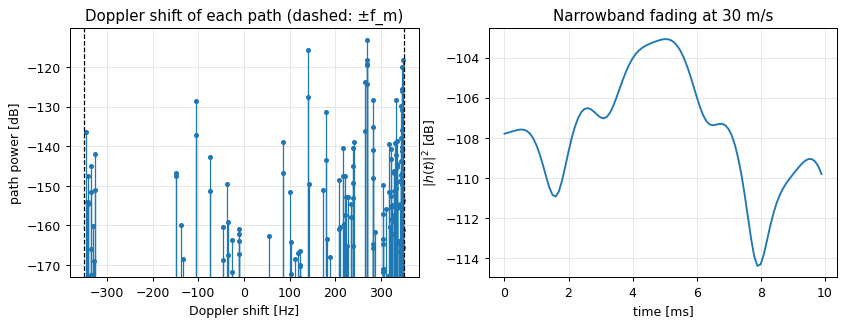

In [22]:
scene = make_city_scene()
v = np.array([30.0, 0.0, 0.0])                    # RX-NLoS moving at 30 m/s (108 km/h) along x
scene.get("rx-nlos").velocity = v.tolist()
paths_mob = solver(scene, max_depth=5, diffraction=True, refraction=False, samples_per_src=RAYS,
                   seed=SEED)

valid = paths_mob.valid.numpy()[1, 0, :]
f_d = paths_mob.doppler.numpy()[1, 0, valid]
th, ph = paths_mob.theta_r.numpy()[1, 0, valid], paths_mob.phi_r.numpy()[1, 0, valid]
r_hat = np.stack([np.sin(th)*np.cos(ph), np.sin(th)*np.sin(ph), np.cos(th)], axis=-1)
lam = speed_of_light/scene.frequency[0]
print(f"max Doppler f_m = v/lambda = {np.linalg.norm(v)/lam:.1f} Hz")
print(f"largest |Sionna - v.r_hat/lambda| over {valid.sum()} paths: {np.max(np.abs(f_d - r_hat @ v/lam)):.2e} Hz")
a, _, _ = path_list(paths_mob, 1)
p = np.abs(a)**2
f_mean = np.sum(p*f_d)/p.sum()
f_rms = np.sqrt(np.sum(p*(f_d - f_mean)**2)/p.sum())
print(f"power-weighted mean Doppler shift {f_mean:.0f} Hz, RMS Doppler spread {f_rms:.0f} Hz "
      f"(isotropic scattering, Clarke: 0 Hz and f_m/sqrt(2) = {np.linalg.norm(v)/lam/np.sqrt(2):.0f} Hz)")

fs, n_t = 10e3, 100                                # 10 ms: the receiver moves 0.3 m (3.5 wavelengths)
a_t, _ = paths_mob.cir(sampling_frequency=fs, num_time_steps=n_t, out_type="numpy")
h_t = a_t[1, 0, 0, 0, :, :].sum(axis=0)           # narrowband channel: coherent sum of the paths
p_db = 10*np.log10(p)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.vlines(f_d, p_db.max() - 60, p_db, lw=1)
ax1.plot(f_d, p_db, "o", ms=3)
for sign in (-1, 1):
    ax1.axvline(sign*np.linalg.norm(v)/lam, color="k", ls="--", lw=1)
ax1.set(xlabel="Doppler shift [Hz]", ylabel="path power [dB]", ylim=(p_db.max() - 60, p_db.max() + 3),
        title="Doppler shift of each path (dashed: ±f_m)")
ax2.plot(np.arange(n_t)/fs*1e3, 20*np.log10(np.abs(h_t)))
ax2.set(xlabel="time [ms]", ylabel="$|h(t)|^2$ [dB]", title="Narrowband fading at 30 m/s");

**What we see and why.** Sionna's Doppler shifts match $\mathbf v\cdot\hat{\mathbf r}/\lambda$ for
every path, and all lie within $\pm f_m=\pm 350$ Hz. The paths arrive from different directions,
so they have different Doppler shifts and their sum varies in time. Here most of the power
arrives from ahead of the receiver: the power-weighted mean Doppler shift is about +260 Hz and
the RMS Doppler spread only about 80 Hz, against 0 Hz and $f_m/\sqrt2\approx 250$ Hz in Clarke's
model, where power arrives uniformly from all directions. The strong paths therefore beat slowly:
over 10 ms the gain varies by about 10 dB, with minima several ms apart instead of the
$\lambda/2v\approx 1.4$ ms spacing of isotropic scattering. Fading statistics are site-specific
too.

> **Instructor notes**
> - **Emphasise:** Doppler is the time signature of the spatial interference pattern; the Doppler-based time evolution is valid only over short displacements (paths do not change).
> - **Ask the class:** a 5G NR slot lasts 0.5 ms with 30 kHz subcarriers. Is the channel roughly constant over a slot at 30 m/s and 3.5 GHz?
>   *Expected answer:* yes, roughly: with Clarke's model the coherence time is about $0.423/f_m\approx 1.2$ ms, longer than the slot; here the Doppler spread is smaller, so the channel varies even more slowly.
> - **Time:** about 2 min.

## 12. Limitations and good practice

A ray tracer is a **model**, not the ground truth. Four practical issues:

1. **Transmission through buildings.** The buildings of the scene are empty shells whose walls
   are single 0.1 m slabs: no floors, interior walls or furniture. With `refraction=True`, rays
   cross entire buildings with little loss.
2. **Convergence.** Paths and radio maps come from a finite number of rays: too few rays miss
   paths (`PathSolver`) or give noisy maps (`RadioMapSolver`). Results must be checked against
   the number of rays, and the cost grows with it.
3. **Materials.** ITU-R P.2040 parameters are average fits, valid only in given frequency ranges;
   real walls are layered and rough.
4. **Geometry and numerics.** Simplified buildings (no windows, balconies, vegetation, vehicles);
   single precision (the two-ray error grows with distance; huge triangles can lose paths).

In [23]:
scene = make_city_scene()
print("1) RX-NLoS with and without transmission through buildings")
for refraction in [False, True]:
    p = solver(scene, max_depth=5, diffraction=True, refraction=refraction, samples_per_src=RAYS,
               seed=SEED)
    a, _, types = path_list(p, 1)
    pw = np.abs(a)**2
    through = np.array(["T" in t for t in types])
    print(f"   refraction={refraction!s:5s}: G = {10*np.log10(pw.sum()):7.1f} dB, "
          f"{len(a):4d} paths, paths crossing a wall carry {pw[through].sum()/pw.sum()*100:3.0f} % of the power")

1) RX-NLoS with and without transmission through buildings


   refraction=False: G =  -107.8 dB,  182 paths, paths crossing a wall carry   0 % of the power


   refraction=True : G =   -90.6 dB,  198 paths, paths crossing a wall carry  98 % of the power


In [24]:
print("2a) PathSolver at RX-NLoS vs number of rays per source")
for n in [10**3, 10**4, 10**5, 10**6, 10**7, 3*10**7]:
    p = solver(scene, max_depth=5, diffraction=True, refraction=False, samples_per_src=n, seed=SEED)
    g_db, n_paths = total_gain_db(p, 1)
    print(f"   samples_per_src = {n:>10,d}: {n_paths:4d} paths, G = {g_db:7.2f} dB")

2a) PathSolver at RX-NLoS vs number of rays per source


   samples_per_src =      1,000:    3 paths, G = -128.23 dB


   samples_per_src =     10,000:   12 paths, G = -121.16 dB


   samples_per_src =    100,000:   43 paths, G = -112.13 dB


   samples_per_src =  1,000,000:  106 paths, G = -108.46 dB
   samples_per_src = 10,000,000:  182 paths, G = -107.80 dB


   samples_per_src = 30,000,000:  212 paths, G = -107.82 dB


2b) RadioMapSolver (max_depth=3) vs number of rays, compared with 10^8 rays


       100,000 rays:  0.53 s, cells reached  51.4 % of the reference, median |error| 1.37 dB


     1,000,000 rays:  0.53 s, cells reached  74.7 % of the reference, median |error| 0.39 dB


    10,000,000 rays:  0.53 s, cells reached  91.8 % of the reference, median |error| 0.10 dB


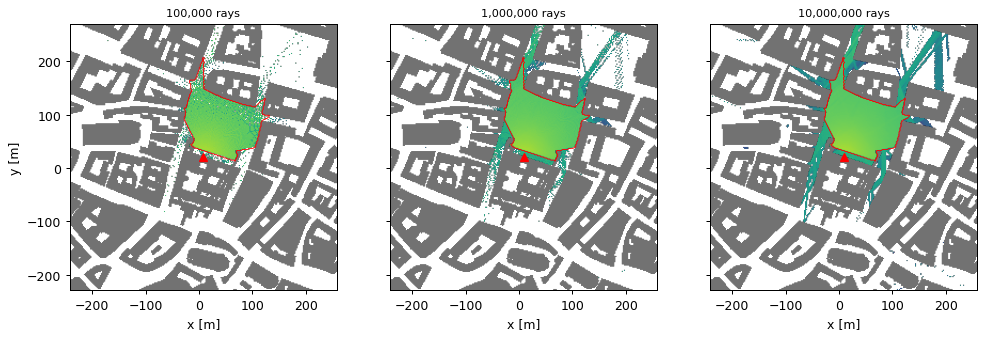

In [25]:
print("2b) RadioMapSolver (max_depth=3) vs number of rays, compared with 10^8 rays")
ref = rm_solver(scene, **dict(MAP_ARGS, max_depth=3, samples_per_tx=10**8)).path_gain.numpy()[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)
for ax, n in zip(axes, [10**5, 10**6, 10**7]):
    t0 = time.time()
    g = rm_solver(scene, **dict(MAP_ARGS, max_depth=3, samples_per_tx=n)).path_gain.numpy()[0]
    seconds = time.time() - t0
    common = (ref > 0) & (g > 0)
    err_db = np.abs(10*np.log10(g[common]/ref[common]))
    print(f"   {n:>11,d} rays: {seconds:5.2f} s, cells reached {np.sum(g > 0)/np.sum(ref > 0)*100:5.1f} % "
          f"of the reference, median |error| {np.median(err_db):.2f} dB")
    show_map(ax, g, f"{n:,d} rays")
    ax.set_xlabel("x [m]")
axes[0].set_ylabel("y [m]");

In [26]:
print("3) ITU materials outside their frequency range")
test_scene = load_scene(sionna.rt.scene.simple_reflector, merge_shapes=False)
test_scene.get("reflector").radio_material = ITURadioMaterial("dry-ground", "medium_dry_ground")
try:
    test_scene.frequency = 28e9
except ValueError as err:
    print("   ValueError:", err)

3) ITU materials outside their frequency range
   ValueError: Properties of ITU material 'medium_dry_ground' are not defined for this frequency


**What we see and why.**
1. With transmission enabled, the NLoS receiver gains about 17 dB and almost all of its power
   crosses buildings. Real buildings attenuate much more (interior walls, floors, furniture), so
   for outdoor studies with these scenes we keep `refraction=False`.
2. Paths are computed exactly once they are found, but finding them takes enough rays: with
   $10^3$ rays $G$ is 20 dB too low, with the default $10^6$ still about 0.6 dB too low, and from
   $10^7$ rays it changes by less than 0.05 dB (the number of paths keeps growing, but only with
   very weak diffracted paths). Radio maps converge as a Monte Carlo estimate: between $10^5$ and
   $10^7$ rays the median error drops from about 1.4 dB to 0.1 dB, roughly as $1/\sqrt{N}$, and
   more and more cells are reached. On a CPU the run time grows with $N$ (in our test with two
   CPU threads: about 0.5, 0.7 and 2.5 s for $10^5$, $10^6$ and $10^7$ rays); on a GPU, maps of
   this size take about half a second whatever $N$.
3. Sionna refuses to use a material outside the frequency range of its ITU model.

**Good practice:** check convergence (rays, `max_depth`), state which mechanisms are enabled,
use the best geometry available, treat material parameters as uncertain, and **validate against
measurements** before using a ray tracer for planning. Differentiable ray tracing can calibrate
the material parameters from measured data.

> **Instructor notes**
> - **Emphasise:** results depend on modelling choices; always report them (mechanisms, max_depth, rays, materials) and validate against measurements.
> - **Ask the class:** name two measurements you would make before trusting this model to plan a network in this square.
>   *Expected answer:* drive-test path gains at LoS and NLoS points to calibrate the materials; a wideband channel sounder to check delay spreads; a site visit for missing geometry (trees, kiosks, vehicles).
> - **Time:** about 3 min.

## 13. Summary

- Ray tracing gives **site-specific** channels: paths with gains, delays, angles and Doppler
  shifts, from which we derive the CIR, PDP, delay spread, frequency response and radio maps.
- It applies the theory you know: **Friis** and the **Fresnel coefficients** (two-ray model)
  are reproduced to a fraction of a dB, as long as both sides use the same assumptions.
- **NLoS is not one thing:** the power arrives through diffraction and multiple reflections in
  proportions that depend on the geometry, and the delay spread and coherence bandwidth follow.
- Results depend on **modelling choices** (mechanisms, max_depth, number of rays, materials,
  geometry): report them, check convergence, validate against measurements.
- **Next:** the lab, where you implement these checks yourselves in a street canyon.

## References

1. Sionna RT documentation (version 2.2.0): https://nvlabs.github.io/sionna/rt/index.html
   and its EM primer: https://nvlabs.github.io/sionna/rt/em_primer.html
2. F. Aït Aoudia, J. Hoydis, M. Nimier-David, S. Cammerer, A. Keller, "Sionna RT: Technical
   Report", arXiv:2504.21719, 2025. https://arxiv.org/abs/2504.21719
3. J. Hoydis, F. Aït Aoudia, S. Cammerer, M. Nimier-David, N. Binder, G. Marcus, A. Keller,
   "Sionna RT: Differentiable Ray Tracing for Radio Propagation Modeling", arXiv:2303.11103, 2023.
   https://arxiv.org/abs/2303.11103
4. ITU-R P.2040-4 (09/2025), "Effects of building materials and structures on radiowave
   propagation in the range of 1 MHz to 450 GHz". https://www.itu.int/rec/R-REC-P.2040-4-202509-I/en
5. 3GPP TR 38.901 V19.5.0 (2026-09), "Study on channel model for frequencies from 0.5 to 100 GHz".
   https://www.3gpp.org/ftp/Specs/archive/38_series/38.901/
6. R. G. Kouyoumjian, P. H. Pathak, "A uniform geometrical theory of diffraction for an edge in a
   perfectly conducting surface", Proc. IEEE, vol. 62, no. 11, pp. 1448-1461, Nov. 1974.
7. M. Hata, "Empirical formula for propagation loss in land mobile radio services", IEEE Trans.
   Veh. Technol., vol. VT-29, no. 3, pp. 317-325, Aug. 1980; COST Action 231, "Digital mobile
   radio towards future generation systems", final report, 1999.
8. T. S. Rappaport, *Wireless Communications: Principles and Practice*, 2nd ed., Prentice Hall,
   2002; A. F. Molisch, *Wireless Communications: From Fundamentals to Beyond 5G*, 3rd ed.,
   Wiley-IEEE Press, 2023.

> **Instructor notes**
> - **Emphasise:** the five messages above; point to the lab.
> - **Ask the class:** which of today's results surprised you most, and why?
>   *Expected answer:* open question (typical answers: the 40+ dB of diffraction at the NLoS receiver, the coherence bandwidth rule failing in LoS, the slab thickness in the two-ray model).
> - **Time:** about 1 min.